# Guardian SVD Exploration

This notebook explores the truncated-SVD representation for the Guardian opinion dataset using the backend utilities already built in this repo.

It mirrors the classroom SVD demo, but on this project's own article corpus.

What it covers:
- building or loading an SVD index for the Guardian dataset
- plotting singular values and cumulative explained variance
- inspecting the top terms for latent dimensions
- projecting queries into latent space and examining their top dimensions
- comparing raw TF-IDF search against truncated-SVD search
- exploring nearest articles in latent space


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (path / 'backend').exists() and (path / 'data').exists()
    ),
    Path.cwd().resolve(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from backend.services.retrieval_service import tfidf_cos_search
from backend.text_processing.svd_processor import (
    DEFAULT_INDEX_DIR,
    DEFAULT_SVD_INDEX_NAME,
    DEFAULT_SVD_N_COMPONENTS,
    load_svd_index,
    preprocess_svd_index,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 140)
PROJECT_ROOT


PosixPath('/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear')

In [9]:
YEARS = list(range(2015, 2026))
N_COMPONENTS = 1000
INDEX_DIR = DEFAULT_INDEX_DIR
INDEX_NAME = DEFAULT_SVD_INDEX_NAME
FORCE_REBUILD = False

TOP_N = 8
QUERY = 'climate migration labor rights'
TITLE_QUERY = 'climate'
DIMENSIONS_TO_INSPECT = list(range(10))
TOP_TERMS_PER_DIMENSION = 8

print(f'YEARS: {YEARS[0]}-{YEARS[-1]}')
print(f'N_COMPONENTS: {N_COMPONENTS}')
print(f'INDEX_NAME: {INDEX_NAME}')
print(f'INDEX_DIR: {INDEX_DIR}')


YEARS: 2015-2025
N_COMPONENTS: 1000
INDEX_NAME: guardian_tfidf_svd
INDEX_DIR: /Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index


In [10]:
build_result = preprocess_svd_index(
    index_dir=INDEX_DIR,
    index_name=INDEX_NAME,
    years=YEARS,
    n_components=N_COMPONENTS,
    force_rebuild=FORCE_REBUILD,
)
build_result


{'built': True,
 'db_row_count': 66331,
 'index_dir': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index',
 'index_name': 'guardian_tfidf_svd',
 'n_components': 1000,
 'requested_n_components': 1000,
 'paths': {'vectorizer': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index/guardian_tfidf_svd_vectorizer.pkl',
  'terms': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index/guardian_tfidf_svd_terms.json',
  'doc_ids': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index/guardian_tfidf_svd_doc_ids.json',
  'articles': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index/guardian_tfidf_svd_articles.pkl',
  'doc_embeddings': '/Users/stevenzhou/Desktop/StevenZhou/Undergraduate/INFO4300/hearhear/data/processed/vector_index/guardian_tfidf_svd_doc_embeddings.npy',
  'c

In [11]:
svd_index, svd_meta = load_svd_index(
    index_dir=INDEX_DIR,
    index_name=INDEX_NAME,
    load_articles=True,
)
diagnostics = svd_index.diagnostics()
articles = svd_index.articles.copy()

print(f"Loaded SVD index '{INDEX_NAME}'")
print(f"Documents: {diagnostics['n_docs']:,}")
print(f"Terms: {diagnostics['n_terms']:,}")
print(f"Effective dimensions: {diagnostics['n_components']}")
print(f"Requested dimensions: {diagnostics['requested_n_components']}")
print(f"Explained variance ratio sum: {diagnostics['explained_variance_ratio_sum']:.4f}")

articles[['id', 'title', 'year']].head(10)


Loaded SVD index 'guardian_tfidf_svd'
Documents: 66,331
Terms: 131,077
Effective dimensions: 1000
Requested dimensions: 1000
Explained variance ratio sum: 0.3443


,id,title,year
0,commentisfree/2015/jan/01/challenge-to-old-order-growing,"All over the world, the challenge to the old order is growing",2015
1,commentisfree/2015/jan/01/surveillance-2015-everything-play-for,"When it comes to surveillance, there is everything to play for",2015
2,commentisfree/2015/jan/01/sleep-new-years-resolution-success,Sleep your way to new year’s resolution success,2015
3,commentisfree/2015/jan/01/2015-general-election-russell-brand-revolution-young-people-vote,If the 2015 general election will be your first – this is your moment,2015
4,commentisfree/2015/jan/01/new-year-political-messages,New year: the season for grandstanding,2015
5,commentisfree/oliver-burkeman-column/2015/jan/01/detoxing-debunked,'Detoxing' has been debunked. Maybe it's time to debunk that,2015
6,commentisfree/2015/jan/01/write-about-who-you-are-not-who-you-want-to-become,"A letter to myself: Write about who you are, not who you want to become",2015
7,commentisfree/2015/jan/01/dear-tony-blair-electorate-shifted-left-ed-miliband,"Dear Tony Blair, maybe it’s your fault if the electorate hasn’t shifted to the left",2015
8,commentisfree/2015/jan/01/serial-adnan-syed-exonerated-new-trial,Will Serial's Adnan Syed ever be exonerated or get a new trial?,2015
9,commentisfree/2015/jan/01/diet-advice-fat-gp,Why not take diet advice from a fat GP? They’re only human,2015


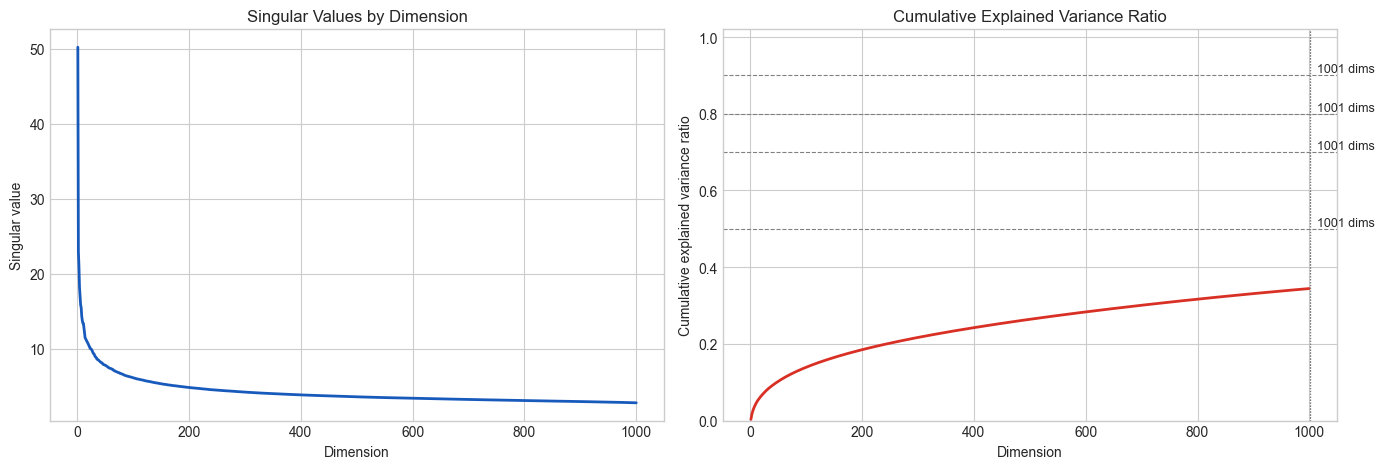

50% cumulative variance -> 1001 dimensions
70% cumulative variance -> 1001 dimensions
80% cumulative variance -> 1001 dimensions
90% cumulative variance -> 1001 dimensions


,dimension,singular_value,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,50.236004,0.002913,0.002913
1,2,22.975483,0.008113,0.011026
2,3,20.971727,0.006869,0.017895
3,4,18.181074,0.005157,0.023053
4,5,16.958769,0.004492,0.027545
5,6,15.865625,0.003934,0.031479
6,7,15.499981,0.003749,0.035228
7,8,14.340684,0.003214,0.038441
8,9,13.784729,0.002970,0.041411
9,10,13.427456,0.002815,0.044226


In [12]:
diagnostics_df = pd.DataFrame({
    'dimension': np.arange(1, diagnostics['n_components'] + 1),
    'singular_value': diagnostics['singular_values'],
    'explained_variance_ratio': diagnostics['explained_variance_ratio'],
    'cumulative_explained_variance_ratio': diagnostics['cumulative_explained_variance_ratio'],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(
    diagnostics_df['dimension'],
    diagnostics_df['singular_value'],
    linewidth=2,
    color='#185abc',
)
axes[0].set_title('Singular Values by Dimension')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Singular value')

axes[1].plot(
    diagnostics_df['dimension'],
    diagnostics_df['cumulative_explained_variance_ratio'],
    linewidth=2,
    color='#d93025',
)
for threshold in (0.5, 0.7, 0.8, 0.9):
    dims_needed = int(
        np.searchsorted(
            diagnostics_df['cumulative_explained_variance_ratio'].to_numpy(),
            threshold,
        ) + 1
    )
    axes[1].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axes[1].axvline(dims_needed, color='gray', linestyle=':', linewidth=0.8)
    axes[1].text(dims_needed, threshold, f'  {dims_needed} dims', va='bottom', fontsize=9)

axes[1].set_ylim(0, 1.02)
axes[1].set_title('Cumulative Explained Variance Ratio')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Cumulative explained variance ratio')

plt.tight_layout()
plt.show()

for threshold in (0.5, 0.7, 0.8, 0.9):
    dims_needed = int(
        np.searchsorted(
            diagnostics_df['cumulative_explained_variance_ratio'].to_numpy(),
            threshold,
        ) + 1
    )
    print(f'{threshold:.0%} cumulative variance -> {dims_needed} dimensions')

diagnostics_df.head(10)


In [13]:
diagnostics_df

,dimension,singular_value,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,50.236004,0.002913,0.002913
1,2,22.975483,0.008113,0.011026
2,3,20.971727,0.006869,0.017895
3,4,18.181074,0.005157,0.023053
4,5,16.958769,0.004492,0.027545
...,...,...,...,...
995,996,2.824048,0.000125,0.343779
996,997,2.822651,0.000125,0.343903
997,998,2.819492,0.000124,0.344028
998,999,2.818215,0.000124,0.344152


In [ ]:
def format_term_list(term_weights):
    return ', '.join(f'{term} ({weight:.3f})' for term, weight in term_weights)


def dimension_summary_frame(index, dimensions, top_n=8):
    rows = []
    for dim in dimensions:
        summary = index.dimension_summary(dim, top_n=top_n)
        rows.append({
            'dimension': dim,
            'positive_terms': format_term_list(summary['positive_terms']),
            'negative_terms': format_term_list(summary['negative_terms']),
            'absolute_terms': format_term_list(summary['absolute_terms']),
        })
    return pd.DataFrame(rows)


dimension_summary_frame(
    svd_index,
    DIMENSIONS_TO_INSPECT,
    top_n=TOP_TERMS_PER_DIMENSION,
)


TypeError: 'int' object is not iterable

In [16]:
def format_dimensions(dim_pairs):
    return ', '.join(f'd{dim} ({value:.3f})' for dim, value in dim_pairs)


def svd_search_frame(index, query, top_n=8, top_dims=3):
    results = index.search(query, top_n=top_n, return_articles=True)
    rows = []
    for rank, (article, score) in enumerate(results, start=1):
        doc_id = str(article['id'])
        rows.append({
            'rank': rank,
            'score': score,
            'year': article.get('year'),
            'title': article.get('title'),
            'top_dimensions': format_dimensions(
                index.top_dimensions_for_doc(doc_id, top_n=top_dims, normalize=True)
            ),
        })
    return pd.DataFrame(rows)


def tfidf_search_frame(query, top_n=8):
    results = tfidf_cos_search(query, top_n=top_n)
    rows = []
    for rank, article in enumerate(results, start=1):
        rows.append({
            'rank': rank,
            'score': article.get('score'),
            'year': article.get('year'),
            'title': article.get('title'),
        })
    return pd.DataFrame(rows)


display(Markdown(f"### Query: `{QUERY}`"))
print('Query top dimensions:', format_dimensions(svd_index.top_dimensions_for_query(QUERY, top_n=5, normalize=True)))

print('\nSVD search results:')
display(svd_search_frame(svd_index, QUERY, top_n=TOP_N))

print('TF-IDF search results:')
tfidf_search_frame(QUERY, top_n=TOP_N)


### Query: `climate migration labor rights`

Query top dimensions: d7 (0.152), d9 (0.150), d134 (-0.111), d11 (0.110), d23 (0.109)

SVD search results:


,rank,score,year,title,top_dimensions
0,1,0.509641,2015,Mass migration is no ‘crisis’: it’s the new normal as the climate changes,"d0 (0.311), d7 (0.267), d11 (0.224)"
1,2,0.471324,2015,Boats block the view to Labor's most progressive policy stance in years,"d0 (0.274), d119 (0.135), d124 (-0.130)"
2,3,0.469988,2018,There’s a remarkable change in the air – our hostility to migrants is on the retreat,"d0 (0.247), d224 (0.179), d30 (0.149)"
3,4,0.451329,2018,Albanese sends another signal he's ready and willing for the top job,"d0 (0.269), d29 (-0.154), d158 (0.124)"
4,5,0.451205,2015,Labor's dilemma: progress on climate change is the hostage of xenophobia,"d0 (0.248), d28 (0.188), d18 (-0.159)"
5,6,0.450245,2016,It's time ... for Paul Keating to zip it,"d0 (0.339), d27 (0.159), d25 (0.150)"
6,7,0.444754,2024,Kim Carr’s memoir is an elegy for older-style Labor politics. Only time will tell if it’s an elegy for the Labor project itself,"d0 (0.292), d29 (-0.148), d27 (0.145)"
7,8,0.442545,2025,"With friends like Trump, who needs Aukus? ALP members are demanding an answer","d0 (0.294), d2 (0.213), d25 (0.173)"


TF-IDF search results:


RuntimeError: Working outside of application context.

This typically means that you attempted to use functionality that needed
the current application. To solve this, set up an application context
with app.app_context(). See the documentation for more information.

In [17]:
def pick_article(index, title_query=None, article_index=0):
    frame = index.articles.reset_index(drop=True)
    if title_query:
        frame = frame.loc[
            frame['title'].astype('string').str.contains(title_query, case=False, na=False)
        ].reset_index(drop=True)

    if frame.empty:
        raise ValueError('No matching article found. Try a different TITLE_QUERY.')
    if not 0 <= int(article_index) < len(frame):
        raise IndexError(f'article_index {article_index} is out of range for {len(frame)} matches.')
    selected = frame.iloc[int(article_index)]
    return selected


def nearest_articles_to_doc(index, doc_id, top_n=8, top_dims=3):
    seed_idx = index.get_doc_idx_by_id(doc_id)
    sims = index.normalized_doc_embeddings @ index.normalized_doc_embeddings[seed_idx]
    order = np.argsort(-np.asarray(sims, dtype=np.float32))

    rows = []
    for neighbor_idx in order:
        neighbor_idx = int(neighbor_idx)
        if neighbor_idx == seed_idx:
            continue
        article = index.articles.iloc[neighbor_idx]
        neighbor_id = str(article['id'])
        rows.append({
            'score': float(sims[neighbor_idx]),
            'year': article.get('year'),
            'title': article.get('title'),
            'top_dimensions': format_dimensions(
                index.top_dimensions_for_doc(neighbor_id, top_n=top_dims, normalize=True)
            ),
        })
        if len(rows) >= top_n:
            break
    return pd.DataFrame(rows)


seed_article = pick_article(svd_index, title_query=TITLE_QUERY, article_index=0)
seed_doc_id = str(seed_article['id'])

display(Markdown('### Seed article'))
print(seed_article['title'])
print(seed_doc_id)
print('Top dimensions:', format_dimensions(svd_index.top_dimensions_for_doc(seed_doc_id, top_n=5, normalize=True)))

nearest_articles_to_doc(svd_index, seed_doc_id, top_n=TOP_N)


### Seed article

Obama's Keystone veto threat is proof that climate activism works, no matter what the 'insiders' say
commentisfree/2015/jan/06/obama-keystone-veto-climate-activism
Top dimensions: d0 (0.328), d7 (0.218), d9 (0.211), d11 (0.133), d65 (0.118)


,score,year,title,top_dimensions
0,0.554876,2015,Climate activists won the Keystone fight. Great. Now can we actually fight climate change?,"d0 (0.339), d7 (0.263), d9 (0.217)"
1,0.502691,2020,Big Oil is using the coronavirus pandemic to push through the Keystone XL pipeline,"d0 (0.368), d9 (0.156), d7 (0.156)"
2,0.493864,2015,Keystone XL would destroy our native lands. This is why we fight,"d0 (0.207), d7 (0.180), d9 (0.168)"
3,0.492183,2015,Why are Republicans so obsessed with their Keystone pipe dream? For 35 jobs?,"d0 (0.343), d65 (0.174), d15 (-0.115)"
4,0.467645,2016,Every climate protection is in Trump's crosshairs. We must fight now,"d0 (0.340), d7 (0.276), d9 (0.259)"
5,0.466395,2017,"From pipelines to refugees, everything Trump does is connected","d0 (0.395), d2 (0.356), d4 (-0.191)"
6,0.450306,2021,"Biden killed the Keystone Pipeline. Good, but he doesn't get a climate pass just yet","d0 (0.293), d2 (0.221), d9 (0.173)"
7,0.449648,2015,The Guardian view on climate change: Obama’s plan is overdue but welcome all the same,"d0 (0.312), d7 (0.298), d9 (0.257)"
